In [1]:
# Drive bağla
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

base = '/content/drive/MyDrive/KemikAI/data/raw'

# CSV dosyalarını yükle
annotations = os.listdir(f'{base}/RSNA_Annotations')
print("Annotation dosyaları:", annotations)

Mounted at /content/drive
Annotation dosyaları: ['RSNA_Annotations']


In [4]:
boneage_path = f'{base}/RSNA_Annotations/RSNA_Annotations/BONEAGE'
print(os.listdir(boneage_path))

['boneage_train.csv', 'boneage_val.csv', 'gender_test.csv']


In [5]:
df_train = pd.read_csv(f'{boneage_path}/boneage_train.csv')
df_val = pd.read_csv(f'{boneage_path}/boneage_val.csv')

print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("\nTrain ilk 5 satır:")
df_train.head()

Train shape: (12611, 3)
Val shape: (1425, 3)

Train ilk 5 satır:


,ID,Male,Boneage
0,1377,False,180
1,1378,False,12
2,1379,False,94
3,1380,True,120
4,1381,False,82


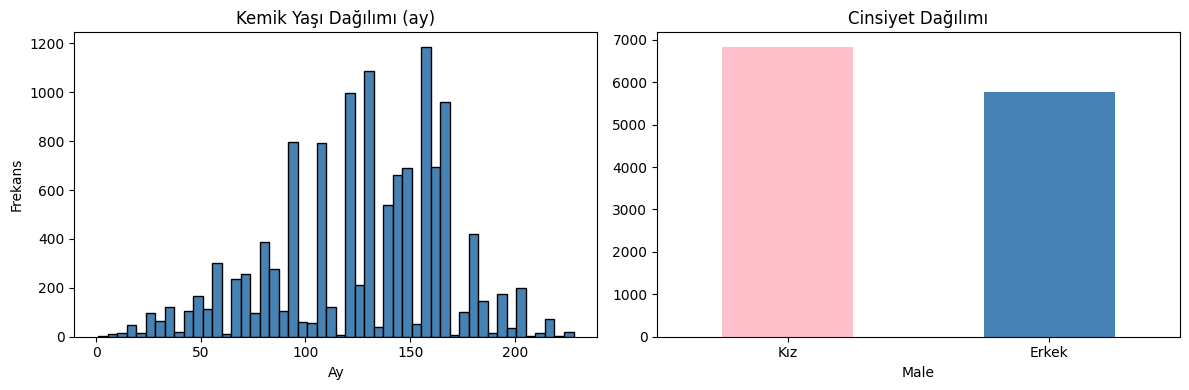

✅ Grafik kaydedildi!


In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_train['Boneage'], bins=50, color='steelblue', edgecolor='black')
plt.title('Kemik Yaşı Dağılımı (ay)')
plt.xlabel('Ay')
plt.ylabel('Frekans')

plt.subplot(1, 2, 2)
df_train['Male'].value_counts().plot(kind='bar', color=['pink', 'steelblue'])
plt.title('Cinsiyet Dağılımı')
plt.xticks([0, 1], ['Kız', 'Erkek'], rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KemikAI/outputs/plots/eda_dagilim.png')
plt.show()
print("✅ Grafik kaydedildi!")

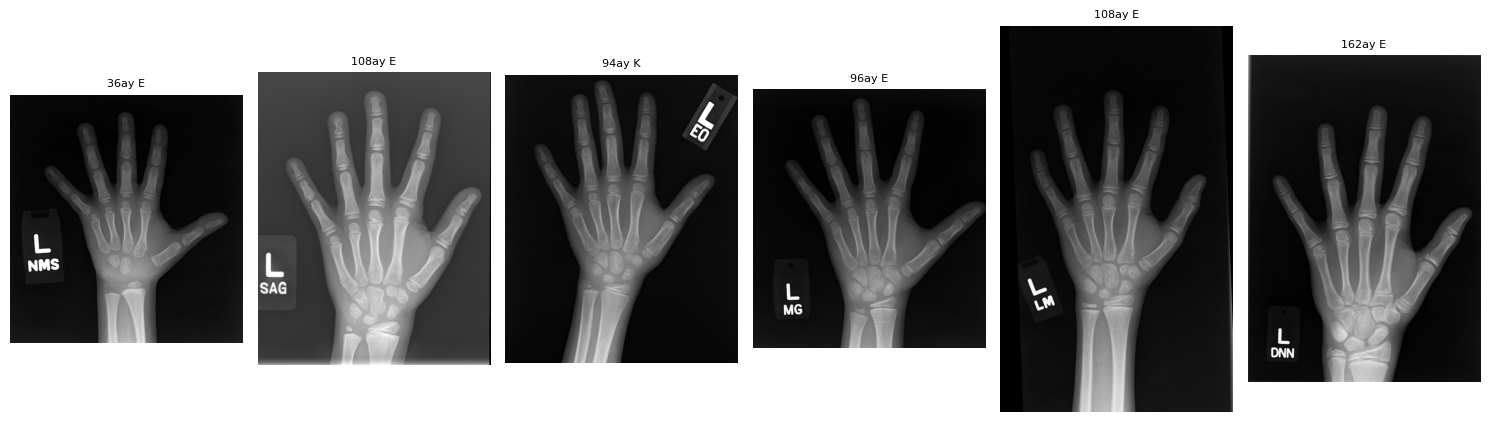

✅ Kaydedildi!


In [10]:
train_img_path = f'{base}/RSNA_train/images'
images = os.listdir(train_img_path)[:6]

plt.figure(figsize=(15, 5))
for i, img_name in enumerate(images):
    img = Image.open(f'{train_img_path}/{img_name}')
    row = df_train[df_train['ID'] == int(img_name.replace('.png',''))]

    plt.subplot(1, 6, i+1)
    plt.imshow(img, cmap='gray')
    if not row.empty:
        ay = row['Boneage'].values[0]
        cinsiyet = 'E' if row['Male'].values[0] else 'K'
        plt.title(f'{ay}ay {cinsiyet}', fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KemikAI/outputs/plots/ornek_goruntuler.png')
plt.show()
print("✅ Kaydedildi!")